<a href="https://colab.research.google.com/github/YagoIbarrola/EML_Carrillo_Ibarrola_Palomar/blob/main/entornos_complejos/src/lunar_SARSA_Deep_QNet.ipynb" target="_parent">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# SARSA Deep Q-Network en el problema LunarLander-v3

*Description*: Implementación y análisis del algoritmo SARSA Semi-gradiente utilizando aproximación de funciones mediante Redes Neuronales Artificiales para resolver el problema LunarLander-v3.

    Authors: Ginés Carrillo Ibáñez, Yago Ibarrola Lapeña, Aarón Palomar Peña
    Emails: gines.carrilloi@um.es, yago.ibarrolal@um.es, aaron.p.p@um.es
    Date: 2026/02/22

## Preparación del entorno


En primer lugar, se instalan las dependencias necesarias para ejecutar el código. En este experimento utilizamos la librería **Gymnasium** junto con la extensión **Box2D**, que permite utilizar el entorno **LunarLander-v3**.

Además, se emplea **PyTorch** para implementar la red neuronal que aproxima la función de valor de acción $Q(s,a)$.

Posteriormente, se importan las clases y funciones necesarias para ejecutar el experimento, incluyendo:

* El agente **SemiGradientSarsaDeepAgent**
* La arquitectura de red **QNetworkSARSA**
* Funciones auxiliares para visualizar métricas de entrenamiento.

Para la reproducibilidad de los resultados, se fija una semilla aleatoria que controla los generadores de números aleatorios utilizados durante el entrenamiento. No obstante, debido a la naturaleza estocástica del entorno y del proceso de entrenamiento, los resultados pueden variar ligeramente entre ejecuciones.

In [1]:
import sys
if 'google.colab' in sys.modules:
    # Definimos que el entorno es Colab
    en_colab = True
    print("Ejecutando en Google Colab")
else:
    # Definimos que el entorno es local
    en_colab = False
    print("Ejecutando en entorno local")

if en_colab:
    #@title Copiar el repositorio.
    print("Clonando el repositorio, tiempo estimado: 1-2 minutos...")
    !git clone https://github.com/YagoIbarrola/EML_Carrillo_Ibarrola_Palomar.git
    !cd EML_Carrillo_Ibarrola_Palomar/

    #@title Importamos todas las clases y funciones
    # Añadir los directorio fuentes al path de Python
    sys.path.append('/content/EML_Carrillo_Ibarrola_Palomar/entornos_complejos/src')
    # Verificar que se han añadido correctamente
    print(sys.path)

    !pip install -r ./EML_Carrillo_Ibarrola_Palomar/requirements.txt

    dir_base = "./EML_Carrillo_Ibarrola_Palomar/entornos_complejos"
else:
    import os
    sys.path.append(os.path.abspath("src"))
    dir_base = "."

Ejecutando en Google Colab
Clonando el repositorio, tiempo estimado: 1-2 minutos...
fatal: destination path 'EML_Carrillo_Ibarrola_Palomar' already exists and is not an empty directory.
['/content', '/env/python', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/usr/local/lib/python3.12/dist-packages', '/usr/lib/python3/dist-packages', '/usr/local/lib/python3.12/dist-packages/IPython/extensions', '/root/.ipython', '/content/EML_Carrillo_Ibarrola_Palomar/entornos_complejos/src']


In [2]:
# @title Instalación e importación de librerías
# !pip install "gymnasium[box2d]" torch numpy matplotlib tqdm

import gymnasium as gym
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import random

from utils import plot_training_metrics
from agents import SemiGradientSarsaDeepAgent, QNetworkSARSA

import imageio
import base64
from IPython.display import HTML
from collections import deque
# Garantizamos reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)


## Experimento

El experimento evalúa el rendimiento de un agente que utiliza el algoritmo on-policy SARSA Semi-gradiente para aprender a aterrizar el módulo lunar. Este entorno consta de:
- **Espacio de estados**: Vector continuo de 8 dimensiones (coordenadas x/y, velocidades x/y, ángulo, velocidad angular, y contacto de las dos patas).
- **Espacio de acciones**: 4 acciones discretas (0: nada, 1: motor izquierdo, 2: motor principal, 3: motor derecho).
- **Recompensa**: Recompensas basadas en la distancia a la plataforma, velocidad, inclinación, uso de combustible y un premio/castigo final de +100/-100 por aterrizar o estrellarse. El entorno se considera **resuelto** si se alcanzan 200 puntos.

Para más detalles, consultar este [notebook](./lunar_SARSAsemi.ipynb).


## Ejecución del experimento

A diferencia de entornos discretos como **Taxi-v3**, el espacio de estados de **LunarLander-v3** es continuo. Por esta razón, resulta imposible utilizar una tabla Q explícita.

Para resolver este problema, se utiliza una **red neuronal artificial** que aproxima la función:

$$
\hat{q}(s,a,w)
$$

donde $w$ representa los parámetros de la red.

**Objetivo del experimento:**
- Implementar el bucle de control de SARSA utilizando backpropagation para aproximar el gradiente $\nabla \hat{q}(S, A, \mathbf{w})$.
- Analizar la curva de aprendizaje y la estabilidad del entrenamiento.
- Estudiar la convergencia de la **recompensa media por episodio**.
- Analizar la evolución de la **duración de los episodios**.
- Observar la evolución del **error de entrenamiento de la red (loss)**.
- Comprobar la capacidad del agente para aprender una **política estable de aterrizaje**.
- Estudiar la influencia de hiperparámetros como:
  * tasa de aprendizaje $\alpha$.
  * políticas **epsilon-greedy** y **epsilon-deacaimiento**.
  * tamaño de la red neuronal.
  

La arquitectura de la red neuronal utilizada es:

* **Capa de entrada:** 8 neuronas (dimensión del estado)
* **Dos capas ocultas:** 128 neuronas totalmente conectadas con activación ReLU
* **Capa de salida:** 4 neuronas que representan los valores $Q(s,a)$ para cada acción

## Entrenamiento

Durante el entrenamiento se ejecutan **2000 episodios**, en los que el agente interactúa con el entorno siguiendo el algoritmo **SARSA Semi-gradiente**.

En cada episodio ocurre lo siguiente:

1. Se reinicia el entorno y se obtiene el estado inicial.
2. El agente selecciona una acción utilizando una **política epsilon-greedy**.
3. El entorno devuelve el nuevo estado $s'$ y la recompensa $r$.
4. El agente selecciona la siguiente acción $a'$ según la misma política.
5. Se calcula el error temporal (TD error):

$$
\delta = r + \gamma Q(s',a',w) - Q(s,a,w)
$$

6. Se actualizan los parámetros de la red neuronal aplicando descenso de gradiente sobre la pérdida:

$$
loss = (Q(s,a,w) - target)^2
$$

7. El proceso se repite hasta que el episodio termina.

Finalmente, el valor de $\epsilon$ se reduce progresivamente para disminuir la exploración y favorecer la explotación de la política aprendida (en el caso de haber decaimiento).

In [3]:
# @title Bucle de Entrenamiento SARSA Semi-gradiente
def train_sarsa_lunar_lander(agent, episodes=2000):
    scores_window = deque(maxlen=100)  # Cola para calcular la media movil de los ultimos 100
    #rewards_history = []
    env = agent.env
    for t in tqdm(range(episodes)):
        state, info = env.reset(seed=t)  # Reproducibilidad en el estado inicial

        action, _ = agent.get_action(state)

        total_reward = 0
        done = False

        while not done:
            # # Tomar acción A, observar R, S'
            # action, _ = agent.get_action(state)

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            # # Elegir A' desde S' usando la política actual
            # next_action = agent.get_action(next_state)

            if not done:
                next_action, _ = agent.get_action(next_state)
            else:
                next_action = None  # no se usará si es terminal

            # Actualizar pesos: w <- w + alpha * [R + gamma*q(S',A') - q(S,A)] * grad(q)
            # agent.update(state, action, reward, next_state, next_action, done)
            agent.update(
                obs=state,
                action=action,
                reward=reward, # Incremento de reward respecto al frame anterior
                terminated=done,
                next_obs=next_state,
                next_action=next_action
            )

            state = next_state
            action = next_action
            total_reward += reward

        agent.decay_epsilon()
        #rewards_history.append(total_reward)
        scores_window.append(total_reward)
        if t % 100 == 0:
            print(f'\rEpisodio {t}\tMedia ultimos 100: {np.mean(scores_window):.2f}')

    env.close()


### SARSA con política $\epsilon$-greedy

En el primer experimento se entrena el agente utilizando una política $\epsilon$-greedy con epsilon constante:

* $\epsilon = 0.05$
* $\gamma = 0.99$
* tasa de aprendizaje $\alpha = 0.001$

In [4]:
n_episodes = 1500
learning_rate = 0.001
start_epsilon = 0.01
epsilon_decay = 0
final_epsilon = 0.01
discount_factor = 0.99


env = gym.make("LunarLander-v3")
env = gym.wrappers.RecordEpisodeStatistics(env, buffer_length=n_episodes)  # Para obtener estadísticas de episodios

agent = SemiGradientSarsaDeepAgent(
    env=env,
    learning_rate=learning_rate,
    epsilon=start_epsilon,
    epsilon_decay=epsilon_decay,
    final_epsilon=final_epsilon,
    discount_factor=discount_factor,
)
# Ejecutar el entrenamiento
train_sarsa_lunar_lander(agent, episodes=n_episodes)


  0%|          | 1/1500 [00:00<10:08,  2.46it/s]

Episodio 0	Media ultimos 100: -269.97


  7%|▋         | 102/1500 [00:18<04:12,  5.54it/s]

Episodio 100	Media ultimos 100: -262.85


 13%|█▎        | 201/1500 [00:58<26:32,  1.23s/it]

...

 87%|████████▋ | 1301/1500 [17:49<01:39,  2.00it/s]

Episodio 1300	Media ultimos 100: 230.22


 93%|█████████▎| 1401/1500 [19:10<00:56,  1.76it/s]

Episodio 1400	Media ultimos 100: 239.15


100%|██████████| 1500/1500 [20:28<00:00,  1.22it/s]


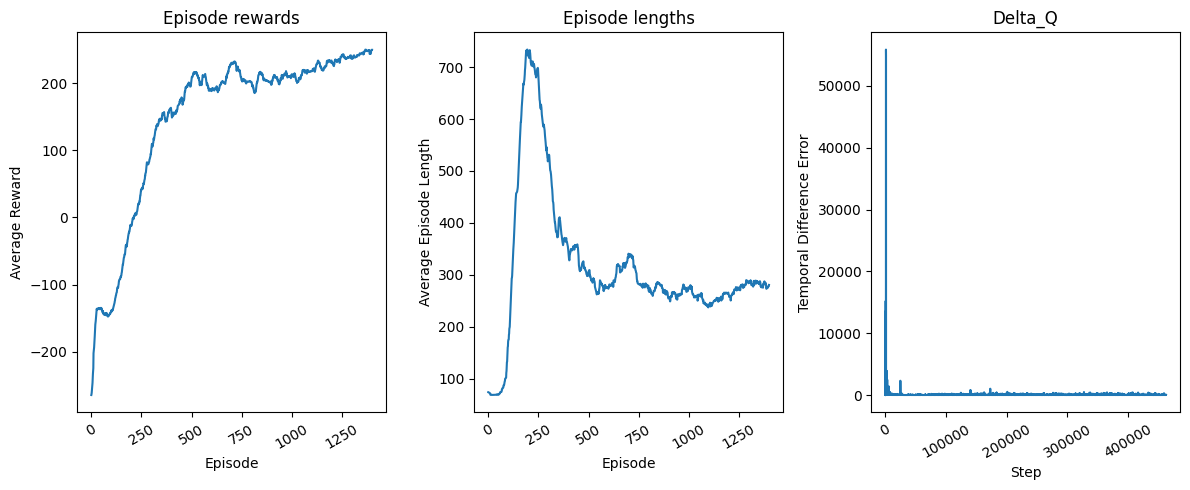

Test Results over 1000 episodes:
Win Rate: 91.6%
Average Reward: 261.607
Standard Deviation: 37.054



In [5]:
plot_training_metrics(env.return_queue, env.length_queue, agent.training_error, rolling_length=100)
agent.test(num_episodes=1000)
print()

En la primera gráfica se observa que, a partir de aproximadamente 500 episodios, el agente comienza a aprender una política que le permite alcanzar una recompensa media cercana a 200, valor que se considera indicativo de un aterrizaje exitoso.

Este comportamiento también se refleja en la segunda gráfica, donde se aprecia que la longitud de los episodios disminuye progresivamente hasta estabilizarse alrededor de los 350 episodios. Al inicio del entrenamiento los episodios son cortos, ya que la nave se estrella rápidamente. A medida que el agente aprende, los episodios se alargan porque logra mantenerse más tiempo en el entorno sin fallar. Posteriormente, cuando ya evita estrellarse de forma consistente, comienza a optimizar su comportamiento reduciendo el uso de combustible, lo que provoca que la duración de los episodios vuelva a acortarse y se estabilice.

Por último, en la tercera gráfica se observa un pico de error muy pronunciado al comienzo del entrenamiento, característico de las primeras fases de aprendizaje, seguido de una evolución mucho más estable durante el resto del proceso.

Tras **1500 episodios de entrenamiento**, el agente alcanza los siguientes resultados en fase de test:

* **Win Rate:** 91.6%
* **Recompensa media:** 261.607
* **Desviación estándar:** 37.054

Estos resultados indican que el agente ha aprendido una política capaz de aterrizar el módulo lunar con bastante frecuencia.

### SARSA con política $\epsilon$-decaimiento

En el segundo experimento se introduce un **decaimiento progresivo de epsilon**, comenzando con una exploración alta y reduciéndola gradualmente a lo largo del entrenamiento.

Parámetros utilizados:

* $\epsilon_0 = 1.0$
* $\lambda = 1/750$ (factor de decaimiento)
* $\epsilon_{final} = 0.01$
* $\gamma = 0.99$
* $\alpha = 0.001$

In [6]:
n_episodes = 1500
learning_rate = 0.001
start_epsilon = 1.0
epsilon_decay = start_epsilon / (n_episodes / 2)
final_epsilon = 0.01
discount_factor = 0.99

env2 = gym.make("LunarLander-v3")
env2 = gym.wrappers.RecordEpisodeStatistics(env2, buffer_length=n_episodes)  # Para obtener estadísticas de episodios

agent2 = SemiGradientSarsaDeepAgent(
    env=env2,
    learning_rate=learning_rate,
    epsilon=start_epsilon,
    epsilon_decay=epsilon_decay,
    final_epsilon=final_epsilon,
    discount_factor=discount_factor,
)
# Ejecutar el entrenamiento
train_sarsa_lunar_lander(agent2, episodes=n_episodes)


  0%|          | 1/1500 [00:00<02:49,  8.85it/s]

Episodio 0	Media ultimos 100: -134.58


  7%|▋         | 102/1500 [00:20<05:41,  4.09it/s]

Episodio 100	Media ultimos 100: -162.30


 13%|█▎        | 202/1500 [00:42<04:54,  4.40it/s]

...

 87%|████████▋ | 1301/1500 [15:46<02:44,  1.21it/s]

Episodio 1300	Media ultimos 100: 220.54


 93%|█████████▎| 1401/1500 [17:12<01:32,  1.08it/s]

Episodio 1400	Media ultimos 100: 224.49


100%|██████████| 1500/1500 [18:17<00:00,  1.37it/s]


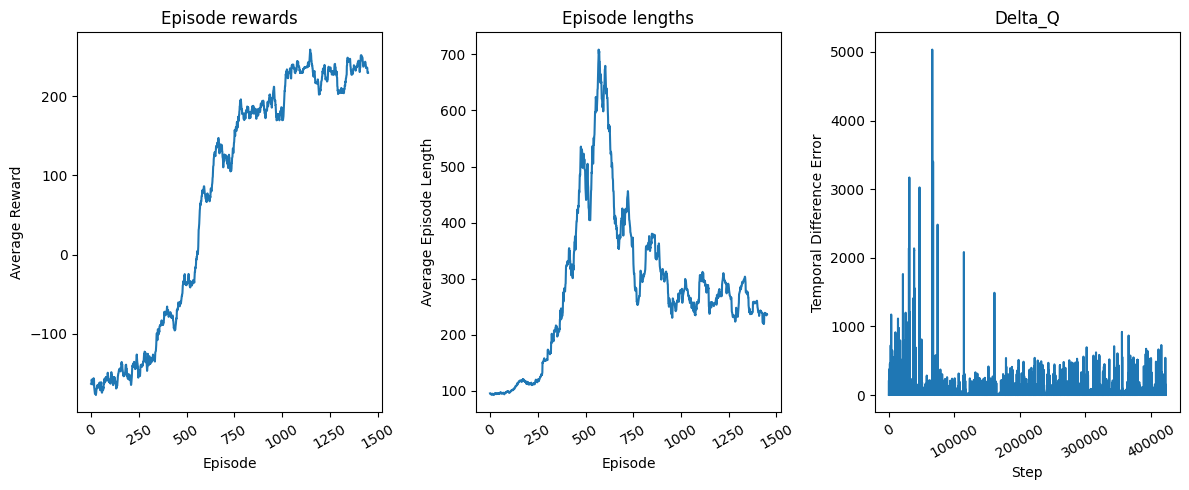

Test Results over 1000 episodes:
Win Rate: 90.0%
Average Reward: 255.089
Standard Deviation: 44.883



In [7]:
plot_training_metrics(env2.return_queue, env2.length_queue, agent2.training_error, rolling_length=50)
agent2.test(num_episodes=1000)
print()

Los resultados obtenidos tras el entrenamiento son:

* **Win Rate:** 90.0%
* **Recompensa media:** 255.089
* **Desviación estándar:** 44.883

Se observa un comportamiento prácticamente idéntico al caso anterior, por lo que el tipo de decaimiento no influye significativamente en los resultados. Por tanto, para una comparación más justa con Deep QLearning, a partir de ahora se empleará $\epsilon$-decaimiento.

### Tasa de aprendizaje $\alpha = 0.01$

Se realizó un experimento adicional aumentando la tasa de aprendizaje a $\alpha = 0.01$

In [8]:
n_episodes = 1500
learning_rate = 0.01
start_epsilon = 1.0
epsilon_decay = start_epsilon / (n_episodes / 2)
final_epsilon = 0.01
discount_factor = 0.99

env3 = gym.make("LunarLander-v3")
env3 = gym.wrappers.RecordEpisodeStatistics(env3, buffer_length=n_episodes)  # Para obtener estadísticas de episodios

agent3 = SemiGradientSarsaDeepAgent(
    env=env3,
    learning_rate=learning_rate,
    epsilon=start_epsilon,
    epsilon_decay=epsilon_decay,
    final_epsilon=final_epsilon,
    discount_factor=discount_factor,
)
# Ejecutar el entrenamiento
train_sarsa_lunar_lander(agent3, episodes=n_episodes)


  0%|          | 1/1500 [00:00<02:43,  9.18it/s]

Episodio 0	Media ultimos 100: -134.58


  7%|▋         | 101/1500 [00:21<07:45,  3.01it/s]

Episodio 100	Media ultimos 100: -174.62


 13%|█▎        | 202/1500 [00:44<04:16,  5.06it/s]

...

 87%|████████▋ | 1301/1500 [17:10<01:47,  1.85it/s]

Episodio 1300	Media ultimos 100: -70.76


 93%|█████████▎| 1401/1500 [18:52<02:07,  1.29s/it]

Episodio 1400	Media ultimos 100: -43.46


100%|██████████| 1500/1500 [20:25<00:00,  1.22it/s]


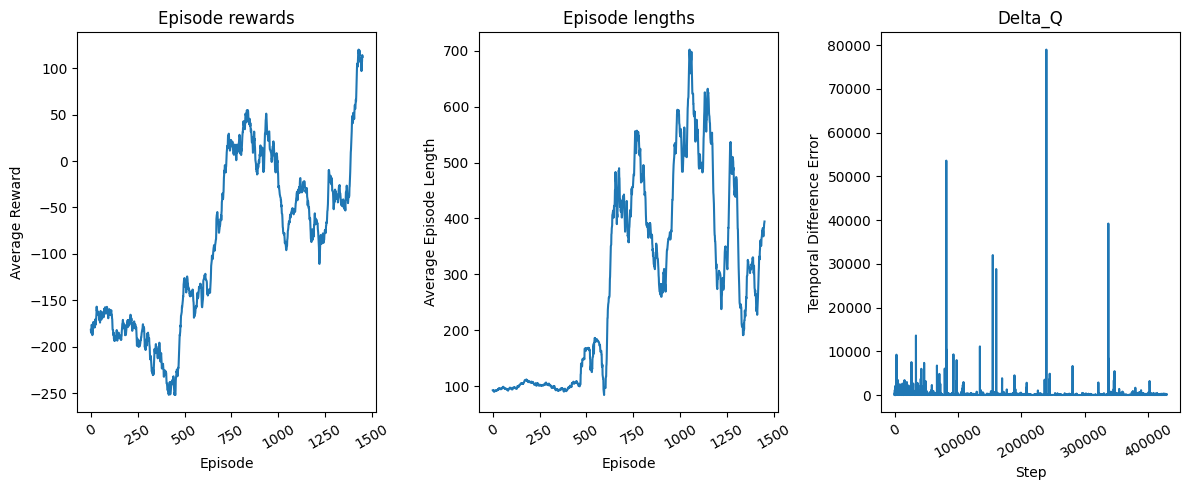

Test Results over 1000 episodes:
Win Rate: 10.9%
Average Reward: 21.019
Standard Deviation: 98.020



In [9]:
plot_training_metrics(env3.return_queue, env3.length_queue, agent3.training_error, rolling_length=50)
agent3.test(num_episodes=1000)
print()

Los resultados fueron muchísimo peores:

* **Win Rate:** 10.9%
* **Recompensa media:** 21.019

Una tasa de aprendizaje demasiado alta provoca actualizaciones excesivamente grandes en los pesos de la red, lo que genera inestabilidad en el proceso de aprendizaje y dificulta la convergencia. En vista de los desastrosos resultados obtenidos, se concluye que una tasa de aprendizaje tan alta no es adecuada para este entorno, por lo que se mantendrá $\alpha = 0.001$ para el resto de experimentos.

### Capas ocultas de 64 neuronas

También se evaluó el efecto del tamaño de las capas ocultas reduciendo la dimensión de la red. En este caso, se utilizó una arquitectura con dos capas ocultas de 64 neuronas cada una.

In [10]:
n_episodes = 1500
learning_rate = 0.001
start_epsilon = 1.0
epsilon_decay = start_epsilon / (n_episodes / 2)
final_epsilon = 0.01
discount_factor = 0.99

env4 = gym.make("LunarLander-v3")
env4 = gym.wrappers.RecordEpisodeStatistics(env4, buffer_length=n_episodes)  # Para obtener estadísticas de episodios

agent4 = SemiGradientSarsaDeepAgent(
    env=env4,
    learning_rate=learning_rate,
    epsilon=start_epsilon,
    epsilon_decay=epsilon_decay,
    final_epsilon=final_epsilon,
    discount_factor=discount_factor,
    hidden_dim=64,
)
# Ejecutar el entrenamiento
train_sarsa_lunar_lander(agent4, episodes=n_episodes)


  0%|          | 1/1500 [00:00<02:38,  9.47it/s]

Episodio 0	Media ultimos 100: -134.58


  7%|▋         | 102/1500 [00:17<03:45,  6.20it/s]

Episodio 100	Media ultimos 100: -182.88


 13%|█▎        | 202/1500 [00:36<03:34,  6.05it/s]

...

 87%|████████▋ | 1301/1500 [13:33<02:24,  1.38it/s]

Episodio 1300	Media ultimos 100: 232.32


 93%|█████████▎| 1401/1500 [14:17<00:37,  2.66it/s]

Episodio 1400	Media ultimos 100: 241.31


100%|██████████| 1500/1500 [15:10<00:00,  1.65it/s]


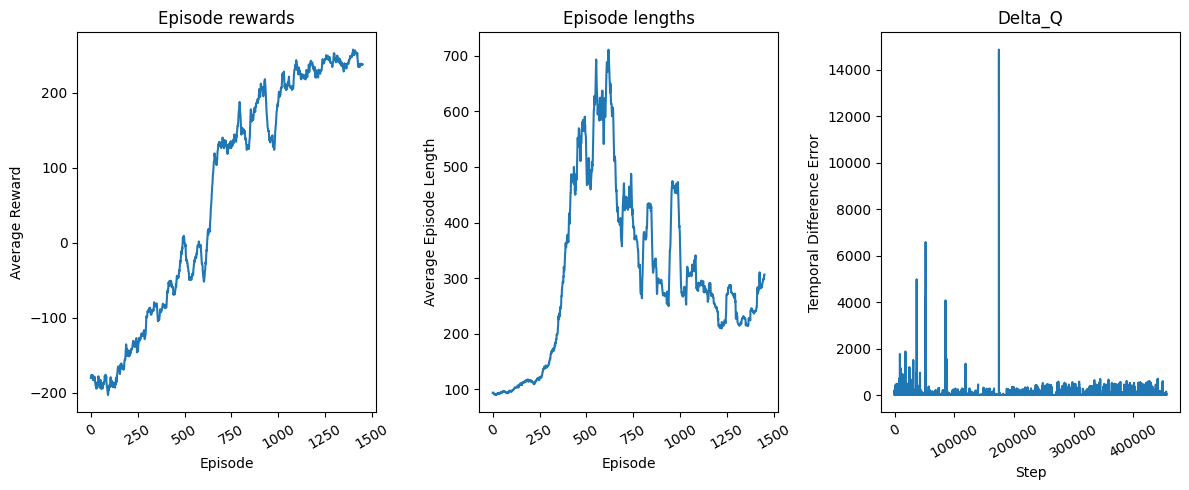

Test Results over 1000 episodes:
Win Rate: 98.5%
Average Reward: 257.613
Standard Deviation: 37.648



In [11]:
plot_training_metrics(env4.return_queue, env4.length_queue, agent4.training_error, rolling_length=50)
agent4.test(num_episodes=1000)
print()

Resultados similares a la red de tamaño 128:

* **Win Rate:** 98.5%
* **Recompensa media:** 257.613

Son resultados prácticamente idénticos a los obtenidos con la red de 128 neuronas, lo que sugiere que el tamaño de la red no es un factor crítico para el rendimiento en este entorno. Se mantendrá la arquitectura de 128 neuronas por ser la baseline.

### Capas ocultas de 32 neuronas
Por último, se probó con una arquitectura aún más pequeña: 32 neuronas en cada capa oculta.

In [12]:
n_episodes = 1500
learning_rate = 0.001
start_epsilon = 1.0
epsilon_decay = start_epsilon / (n_episodes / 2)
final_epsilon = 0.01
discount_factor = 0.99

env5 = gym.make("LunarLander-v3")
env5 = gym.wrappers.RecordEpisodeStatistics(env5, buffer_length=n_episodes)  # Para obtener estadísticas de episodios

agent5 = SemiGradientSarsaDeepAgent(
    env=env5,
    learning_rate=learning_rate,
    epsilon=start_epsilon,
    epsilon_decay=epsilon_decay,
    final_epsilon=final_epsilon,
    discount_factor=discount_factor,
    hidden_dim=32,
)
# Ejecutar el entrenamiento
train_sarsa_lunar_lander(agent5, episodes=n_episodes)


  0%|          | 1/1500 [00:00<02:55,  8.55it/s]

Episodio 0	Media ultimos 100: -134.58


  7%|▋         | 102/1500 [00:18<04:06,  5.68it/s]

Episodio 100	Media ultimos 100: -189.58


 13%|█▎        | 201/1500 [00:36<04:35,  4.72it/s]

...

 87%|████████▋ | 1301/1500 [16:34<02:06,  1.58it/s]

Episodio 1300	Media ultimos 100: -181.01


 93%|█████████▎| 1401/1500 [18:12<00:52,  1.90it/s]

Episodio 1400	Media ultimos 100: 81.73


100%|██████████| 1500/1500 [19:45<00:00,  1.27it/s]


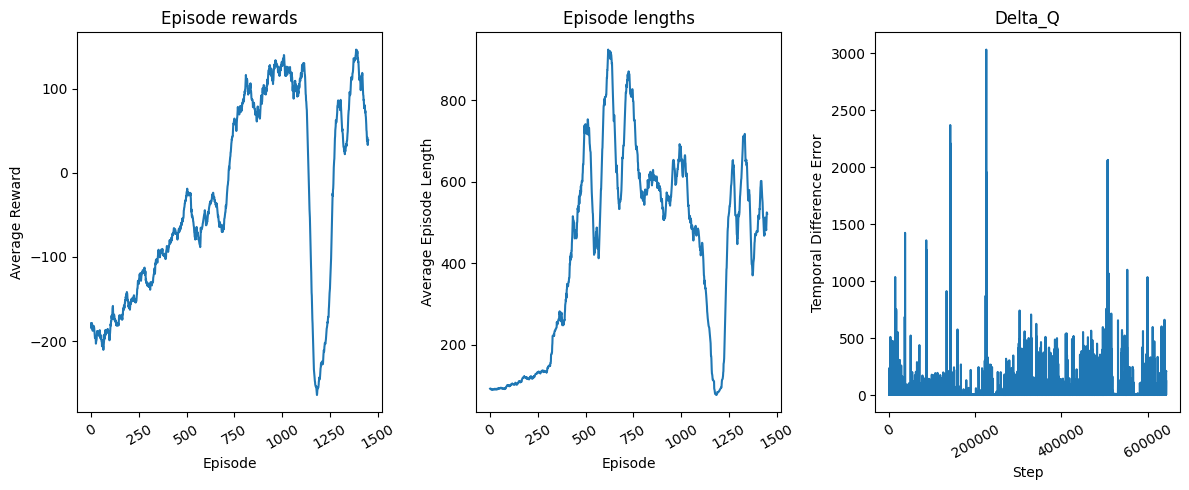

Test Results over 1000 episodes:
Win Rate: 6.0%
Average Reward: 58.854
Standard Deviation: 93.365



In [13]:
plot_training_metrics(env5.return_queue, env5.length_queue, agent5.training_error, rolling_length=50)
agent5.test(num_episodes=1000)
print()

Se obtiene:
* **Win Rate:** 6.0%
* **Recompensa media:** 58.854

En este caso, el rendimiento se desploma, lo que indica que una red tan pequeña no tiene suficiente capacidad de representación para aprender una política efectiva en este entorno. Como consecuencia, la red de 128 neuronas sigue siendo la que obtiene mejores resultados, lo que indica que una mayor capacidad de representación puede ayudar a aprender una mejor política.

## Análisis de Resultados

- Al inicio del entrenamiento, el agente obtiene recompensas cercanas a -200 o -300, ya que las acciones se seleccionan de forma prácticamente aleatoria y el módulo suele estrellarse o salirse de la pantalla.
- A medida que $\epsilon$ decae y los pesos $\mathbf{w}$ se ajustan, la recompensa media aumenta.
- La inestabilidad (gráficas de recompensa que suben a 100 y de repente caen en picado) es una característica de usar Redes Neuronales con métodos on-line como SARSA
- Mientras que en problemas tabulares SARSA y Q-Learning convergen con garantías teóricas, al introducir Redes Neuronales el control del hiperparámetro de tasa de aprendizaje $\alpha$ y la arquitectura de la red determinan la convergencia.
- Una mejora es usar DQN (Deep Q-Networks), que añade un "Buffer de Repetición" para romper la correlación y una "Red Objetivo" (Target Network) para estabilizar el gradiente.

In [14]:
# Guardar pesos del modelo entrenado
torch.save(agent2.q_network.state_dict(), dir_base+"/data/results/SARSADeepLunarLander/sarsa_lunarlander_qnetwork2.pth")
print("Pesos guardados correctamente.")

Pesos guardados correctamente.


Código sacado de este [repositorio](https://github.com/ldaniel-hm/eml_approximate/blob/0730b02e2a973683f400f71d60e92ac24a403d55/SolucionDeepSARSA_CartPole.ipynb#L345)

In [15]:
def greedy_action(q_network, state):
    """
    Selecciona la acción óptima (greedy) para un estado dado utilizando la red Q.

    Parámetros:
      - q_network (QNetwork): Red neuronal con los pesos cargados.
      - state: Estado actual del entorno (puede ser una lista o tensor).

    Retorna:
      - int: Acción que maximiza Q(s,a).
    """
    # Desactivamos el cálculo de gradientes (no es necesario en modo evaluación).
    with torch.no_grad():
        # Convertir el estado a tensor si no lo es y añadir dimensión de batch.
        if not isinstance(state, torch.Tensor):
            state = torch.FloatTensor(state).unsqueeze(0)
        # Calcular los valores Q para el estado.
        q_values = q_network(state)
        # Seleccionar la acción que maximiza Q(s,a).
        action = torch.argmax(q_values).item()
    return action

def run_episode_greedy_lunarlander(env, q_network, max_steps=500):
    """
    Ejecuta un episodio usando la política greedy y captura los fotogramas.

    Parámetros:
      - env: Entorno Gymnasium configurado con render_mode='rgb_array'.
      - q_network: Red neuronal QNetwork con los pesos cargados.
      - max_steps (int): Número máximo de pasos a ejecutar en el episodio.

    Retorna:
      - list: Lista de fotogramas (imágenes) capturados durante el episodio.
    """
    frames = []  # Lista para almacenar cada fotograma.

    # Reiniciar el entorno y obtener el estado inicial.
    state, _ = env.reset()
    done = False  # Indicador de finalización del episodio.

    # Ejecutar el episodio hasta max_steps o hasta que el entorno indique que ha terminado.
    for _ in range(max_steps):
        # Capturar el fotograma actual del entorno.
        frame = env.render()
        frames.append(frame)

        # Seleccionar la acción óptima utilizando la función greedy.
        action = greedy_action(q_network, state)

        # Ejecutar la acción en el entorno y obtener el siguiente estado y otros datos.
        next_state, reward, done, truncated, info = env.step(action)
        state = next_state  # Actualizar el estado.

        # Si el episodio ha terminado o se ha truncado, capturar el fotograma final y salir.
        if done or truncated:
            frames.append(env.render())
            break

    return frames

def frames_to_gif(frames, filename=dir_base+"/data/results/SARSADeepLunarLander/lunarlander_sarsa.gif"):
    """
    Crea un archivo GIF a partir de una lista de fotogramas.

    Parámetros:
      - frames (list): Lista de fotogramas (imágenes) capturados del entorno.
      - filename (str): Nombre del archivo GIF resultante.

    Retorna:
      - str: Nombre del archivo GIF creado.
    """
    # Abrir un escritor de GIF con imageio.
    with imageio.get_writer(filename, mode='I') as writer:
        # Agregar cada fotograma al GIF.
        for frame in frames:
            writer.append_data(frame)
    return filename


def display_gif(gif_path):
    """
    Muestra un GIF en Google Colab.

    Parámetros:
      - gif_path (str): Ruta del archivo GIF.

    Retorna:
      - HTML: Objeto HTML que contiene el GIF incrustado.
    """
    # Abrir el archivo GIF en modo binario.
    with open(gif_path, 'rb') as f:
        video = f.read()
    # Convertir el contenido del GIF a una cadena Base64.
    b64 = base64.b64encode(video)
    # Retornar el objeto HTML que muestra el GIF.
    return HTML(f'<img src="data:image/gif;base64,{b64.decode()}" />')

GIF guardado en: ./EML_Carrillo_Ibarrola_Palomar/entornos_complejos/data/results/SARSADeepLunarLander/lunarlander_sarsa2.gif



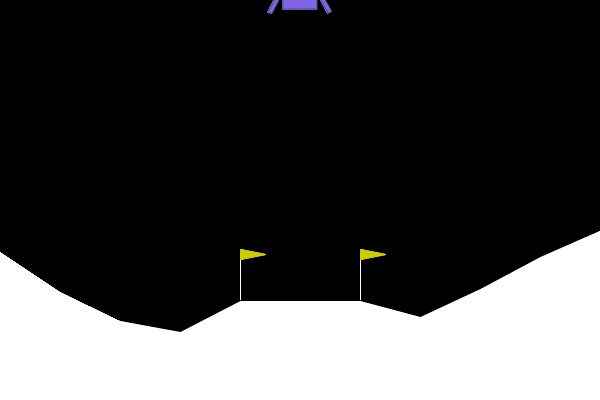

In [16]:
# Crear entorno con modo render para capturar imágenes
env_demo = gym.make("LunarLander-v3", render_mode='rgb_array')

state_dim = env_demo.observation_space.shape[0]
action_dim = env_demo.action_space.n

# Crear una instancia de la red QNetwork.
q_net_loaded = QNetworkSARSA(state_dim, action_dim, hidden_dim=128)

# Cargar pesos
q_net_loaded.load_state_dict(torch.load(dir_base+"/data/results/SARSADeepLunarLander/sarsa_lunarlander_qnetwork2.pth"))

# Poner la red en modo evaluación para asegurar que se comporta correctamente en inferencia.
q_net_loaded.eval()

# Ejecutar un episodio utilizando la política greedy y capturar los fotogramas.
frames = run_episode_greedy_lunarlander(env_demo, q_net_loaded)

# Cerrar el entorno una vez terminado el episodio.
env_demo.close()

# Crear el GIF a partir de los fotogramas capturados.
gif_path = frames_to_gif(frames, filename=dir_base+"/data/results/SARSADeepLunarLander/lunarlander_sarsa2.gif")
print("GIF guardado en:", gif_path)

# Mostrar GIF
display_gif(gif_path)

## Conclusiones

A partir de los experimentos realizados se pueden extraer varias conclusiones relevantes:

- El uso de **epsilon-decay** no aporta una mejora significativa al rendimiento del agente, aunque permite explorar ampliamente el entorno en las primeras fases del entrenamiento y explotar posteriormente la política aprendida.

- El algoritmo es muy sensible al valor de la tasa de aprendizaje. Valores demasiado altos provocan **inestabilidad en la convergencia**

- Incluso redes relativamente pequeñas (64 neuronas) son capaces de aproximar adecuadamente la función de valor en este problema, aunque demasiado pequeñas (32 neuronas) no tienen suficiente capacidad de representación para aprender una política efectiva. Por tanto, una mayor capacidad de representación puede ayudar a aprender una mejor política, aunque no es un factor crítico para el rendimiento en este entorno.